Introduction

The housing market is influenced by a variety of factors, including property size, number of bedrooms, bathrooms and overall housing characteristics. Understanding how these variables affect housing prices is an important task for homeowners, buyers, investors, and real estate professionals.

This project aims to analyze residential housing data and develop a predictive model for estimating house prices. The analysis begins with data cleaning and preprocessing to improve data quality, followed by exploratory data analysis (EDA) to identify relationships and patterns within the dataset. Statistical visualizations are used to examine the distribution of house prices and the correlations between housing features.

To further investigate the relationship between housing characteristics and property values, a Linear Regression model is implemented. The model uses selected housing features, including living area, number of bedrooms, and number of bathrooms, to predict house prices. Model performance is evaluated using the coefficient of determination (R²) and Mean Absolute Error (MAE), providing insight into both the explanatory power and prediction accuracy of the model.

In addition, the project examines the impact of outlier removal on model performance by comparing regression results before and after applying a three-standard-deviation filtering approach. This comparison helps evaluate how extreme observations influence predictive modeling outcomes.

Through data analysis, visualization, and predictive modeling, this project demonstrates a complete data science workflow for housing market analysis and provides insights into the factors that contribute to residential property values.

Data Overview

This project uses a residential housing dataset containing property characteristics and sale prices. The dataset includes information such as living area, number of bedrooms, number of bathrooms, and house prices.

The target variable in this analysis is price, while housing characteristics are used as predictor variables for exploratory analysis and regression modeling.

For the Linear Regression model, the following variables were selected:

Price: Sale price of the property (target variable)
sqft_living: Living area in square feet
Bedrooms: Number of bedrooms
Bathrooms: Number of bathrooms

These features were chosen because they are commonly associated with housing value and provide a reasonable basis for price prediction.

Data Preparation

Overview

Before conducting the analysis, the dataset was reviewed and prepared for exploratory data analysis and predictive modeling. Since the dataset was already preprocessed and contained no significant data quality issues, only a subset of relevant variables was selected for analysis.

Variable Selection

The following variables were selected:

Price: House sale price (target variable)
sqft_living: Living area in square feet
bedrooms: Number of bedrooms
bathrooms: Number of bathrooms
view: the view level

These variables were chosen due to their strong relevance to residential property values and their suitability for regression modeling.

Dataset Summary

In [42]:
import pandas as pd
df = pd.read_csv('Outliers_removed.csv')
summary = df[['price','sqft_living','bedrooms','bathrooms','view']].describe().round(2)
summary

,price,sqft_living,bedrooms,bathrooms,view
count,4566.00,4566.00,4566.00,4566.00,4566.00
mean,527244.81,2115.67,3.39,2.15,0.23
std,305365.46,903.27,0.90,0.76,0.76
min,0.00,370.00,0.00,0.00,0.00
25%,320250.00,1460.00,3.00,1.75,0.00
50%,459995.00,1970.00,3.00,2.25,0.00
75%,650000.00,2600.00,4.00,2.50,0.00
max,2238888.00,8020.00,9.00,6.50,4.00


Outlier Analysis

To investigate the influence of extreme housing prices on model performance, a second dataset was created by removing observations outside three standard deviations from the mean price.

This produced:

Original Dataset
Outliers Removed Dataset

Both datasets were evaluated using the same Linear Regression model and train-test split configuration.

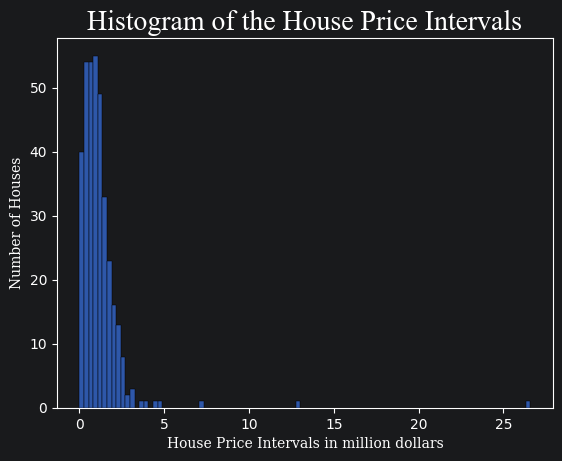

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
table = pd.read_csv('intervals.csv')
font1 = {'family': 'Times New Roman', 'weight': 'normal', 'size': '20'}
font2 = {'family': 'serif', 'weight': 'normal', 'size': '10'}
sns.histplot(
    table['the_start'].apply(lambda x:x/1000000)
)
plt.title('Histogram of the House Price Intervals',fontdict=font1)
plt.xlabel('House Price Intervals in million dollars',fontdict=font2)
plt.ylabel('Number of Houses',fontdict=font2)
plt.savefig('House_Price_Intervals.png')
plt.show()

Most houses are concentrated within the low-price range from 0 to 5 million, while a smaller number of properties exhibit exceptionally high prices, resulting in a right-skewed distribution.

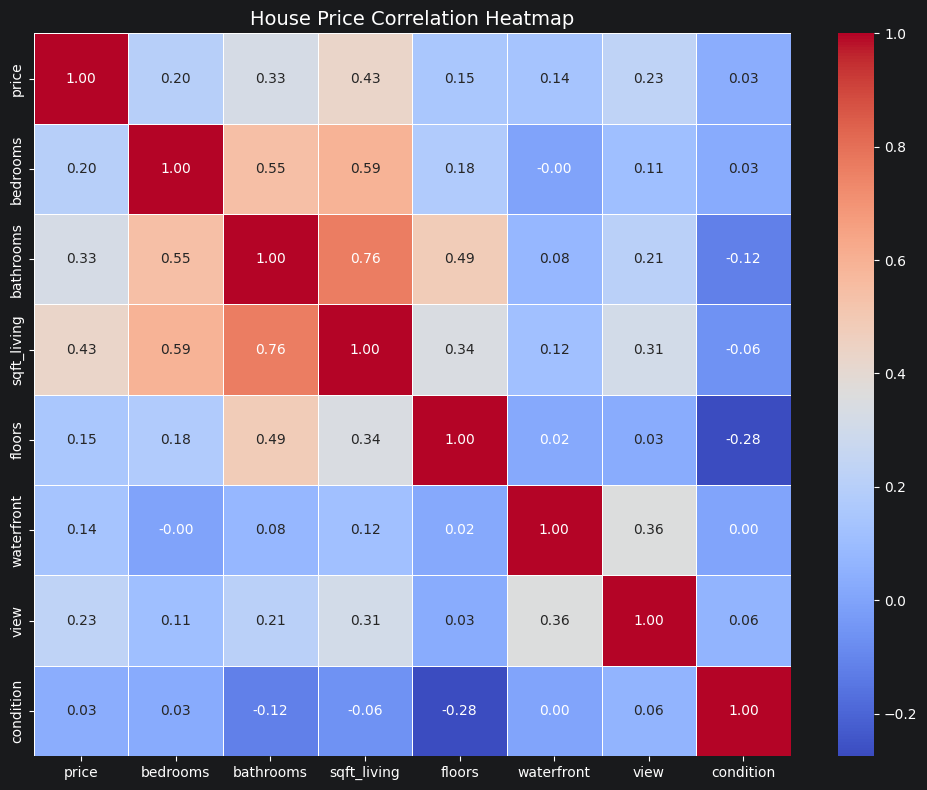

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
main_table = pd.read_csv('modified_data.csv')
col = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'floors',
    'waterfront',
    'view',
    'condition',
]
heatmap_data = main_table[col]
corr_matrix = heatmap_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,
)
plt.title("House Price Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

Based on the correlation analysis, sqft_living, bedrooms, bathrooms, and view were selected as predictors for house price. A Linear Regression model was then trained and evaluated using R^2 and MAE. These features showed positive relationships with house prices and were expected to contribute to prediction performance.

Model Evaluation (After outliers removed):

R^2 = 0.47907715609282553
MAE = 153753.8265639399


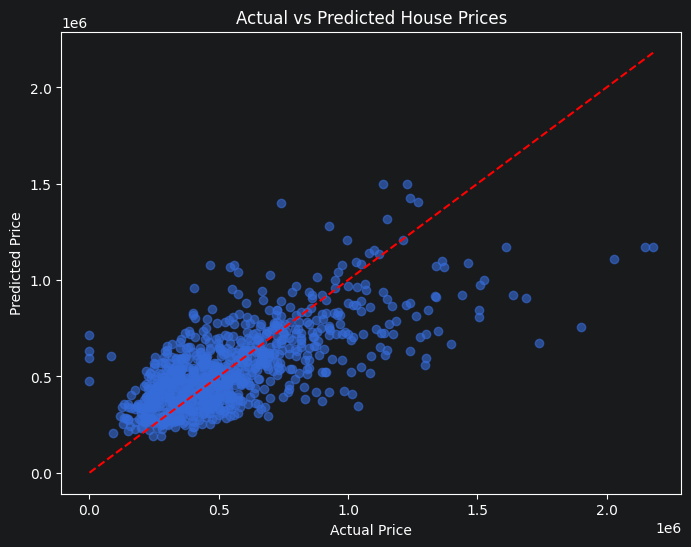

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
df = pd.read_csv('Outliers_removed.csv')
X = df[['sqft_living', 'bedrooms', 'bathrooms','view']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("R^2 =", r2)
print("MAE =", mae)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()

The Linear Regression model achieved an R^2 score of 0.479 and an MAE of $153,754.

The results indicate that approximately 47.9% of the variation in house prices can be explained by the selected housing characteristics. On average, predicted house prices differed from actual prices by approximately $153,754.

Model Evaluation (Before outliers removed):

R^2 = 0.49758474986475576
MAE = 172957.19129394385


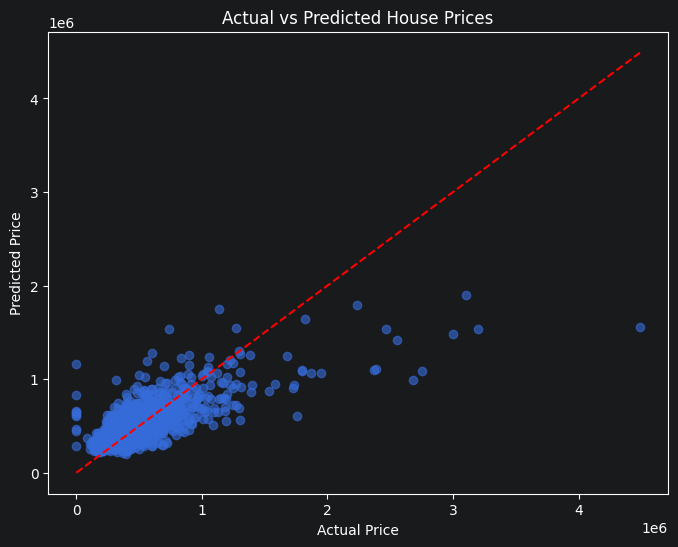

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
df = pd.read_csv('modified_data.csv')
X = df[['sqft_living', 'bedrooms', 'bathrooms','view']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("R^2 =", r2)
print("MAE =", mae)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.savefig("actual_vs_predicted(raw).png")
plt.show()

The Linear Regression model achieved an R^2 score of 0.497 and an MAE of $172,957.

The results indicate that approximately 49.7% of the variation in house prices can be explained by the selected housing characteristics. On average, predicted house prices differed from actual prices by approximately $172,957.

Model Comparison

To evaluate the impact of outlier removal on housing price prediction, Linear Regression models were trained on both the original dataset and the outlier-removed dataset using the same feature set and train-test split configuration.

In [47]:
import pandas as pd
comparison = pd.DataFrame({
'Dataset': ['Original Dataset', 'Outliers Removed Dataset'],
'R^2': [0.498, 0.479],
'MAE ($)': [172957, 153754]})
comparison

,Dataset,R^2,MAE ($)
0,Original Dataset,0.498,172957
1,Outliers Removed Dataset,0.479,153754


Bar Chart Comparison

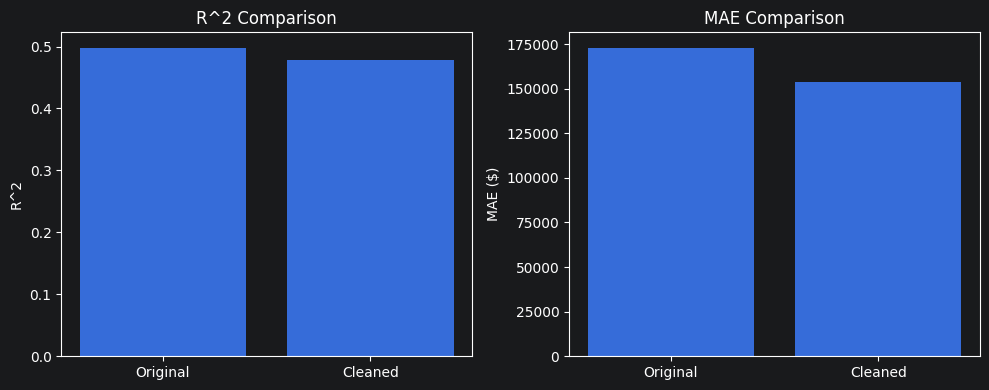

In [48]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].bar(['Original', 'Cleaned'],[0.498, 0.479])
axes[0].set_title('R^2 Comparison')
axes[0].set_ylabel('R^2')
axes[1].bar(['Original', 'Cleaned'],[172957, 153754])
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE ($)')
plt.tight_layout()
plt.savefig('comparison.png')
plt.show()

Interpretation

The model trained on the original dataset achieved a slightly higher R^2 score (0.498), indicating a greater proportion of explained variance in house prices. However, the model trained on the outlier-removed dataset achieved a lower Mean Absolute Error (MAE) of $153,754, compared to 172,957 for the original dataset.

These results suggest that removing extreme observations reduced average prediction error and produced more accurate predictions for typical housing properties, although it slightly reduced the overall variance explained by the model.

Therefore, the outlier-removed dataset was selected as the preferred model for house price prediction due to its lower prediction error.